ML Pipeline Initialization & Advanced Feature Engineering

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Ingest clean cohort data from the upstream pipeline stage
DATA_PATH = os.path.join("..", "data", "processed_cohort_data.csv")
df = pd.read_csv(DATA_PATH)

print(f"📦 Pipeline Step 1: Ingested {df.shape[0]} rows for machine learning pipeline.")

# 2. Dynamic Column Mapping
try:
    gender_col = [col for col in df.columns if 'gender' in col.lower() or 'sex' in col.lower()][0]
    risk_col = [col for col in df.columns if 'risk_of_contracting' in col.lower() or 'likely_is_it' in col.lower()][0]
    rel_col = [col for col in df.columns if 'relationship' in col.lower() or 'status' in col.lower()][0]
    aware_col = [col for col in df.columns if 'aware' in col.lower() and 'testing' in col.lower()][0]
    target_col = [col for col in df.columns if 'ever_tested' in col.lower() or ('ever' in col.lower() and 'test' in col.lower())][0]
except IndexError:
    raise KeyError("Failed to dynamically map the required machine learning features from the dataset.")

# 3. ADVANCED FEATURE ENGINEERING: Map the Relationship Insulation Bias
# Quantify relationship status: 1 for partnered ('In a relationship'/'Married'), 0 for single
df['is_partnered'] = df[rel_col].apply(lambda x: 1 if any(word in str(x).lower() for word in ['relation', 'marr']) else 0)

# Build the interaction term: Partnered Status x Peer Risk Perception
# High values signify individuals who are partnered but highly aware of surrounding risk vectors
df['relationship_insulation_index'] = df['is_partnered'] * df[risk_col]

# 4. Separate Target Array (Y) and Feature Matrix (X)
# We encode Target: 1 for 'Yes' (has tested), 0 for 'No'
y = df[target_col].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0).values

feature_cols = ['age', 'college', gender_col, aware_col, 'relationship_insulation_index']
X = df[feature_cols]

# 5. Define Stratified Train/Test Split (70/30) to protect against minority class imbalances
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"📊 Splitting Complete: Training set shape = {X_train.shape}, Test set shape = {X_test.shape}")
print(f"🎯 Target Screening Base Prevalence: {np.mean(y)*100:.1f}% Ever Tested.")

📦 Pipeline Step 1: Ingested 333 rows for machine learning pipeline.
📊 Splitting Complete: Training set shape = (233, 5), Test set shape = (100, 5)
🎯 Target Screening Base Prevalence: 30.6% Ever Tested.


ML Data Ingestion, Dynamic Variable Mapping and Advanced Feature Engineering

- This initial block secures our raw cohort matrix, isolates our core tracking variables using dynamic string parsing, and engineers an interaction term to capture cognitive insulation patterns. Finally, it separates our target behavior vector and splits the data into a stratified 70/30 division for training and validation.

- Creating a pipeline at this stage guarantees that our data partitions remain structurally identical across experiments. Rather than relying purely on baseline demographic columns, engineering custom interaction terms allow our upcoming classifiers to mathematically test clinical theories, such as how specific relationship structures modify how a student acts on risk awareness.

Preprocessing Pipeline and Classifier Training Strategy

In [4]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Identify feature types dynamically from our training matrix split
numeric_features = ['age', 'relationship_insulation_index']
categorical_features = [col for col in X_train.columns if col not in numeric_features]

print(f"🔧 Preprocessing Setup (With Imputation):")
print(f"   Continuous Variables: {numeric_features}")
print(f"   Categorical Variables: {categorical_features}\n")

# 2. Construct transformers that handle missing values dynamically
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first')) 
])

# 3. Combine transformers into a single composition layer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# 4. Assemble the final end-to-end Machine Learning Pipeline
ml_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, class_weight='balanced'))
])

# 5. Train (Fit) the model smoothly
ml_pipeline.fit(X_train, y_train)

print("🎯 SUCCESS: Missing data imputed automatically and model trained perfectly!")

# 6. Extract engineered feature names post-encoding using named_transformers_
encoded_cat_features = ml_pipeline.named_steps['preprocessor']\
                                  .named_transformers_['cat']\
                                  .named_steps['encoder']\
                                  .get_feature_names_out(categorical_features)
all_transformed_features = numeric_features + list(encoded_cat_features)

print(f"📊 Total Explanatory Features feeding the model: {len(all_transformed_features)}")

🔧 Preprocessing Setup (With Imputation):
   Continuous Variables: ['age', 'relationship_insulation_index']
   Categorical Variables: ['college', 'gender', 'aware_testing_services']

🎯 SUCCESS: Missing data imputed automatically and model trained perfectly!
📊 Total Explanatory Features feeding the model: 10


Preprocessing with Imputation and Feature Mapping

- This step constructs an automated data transformation and imputation layer, safely replacing missing fields via median and statistical mode strategies. It generates 10 unique, fully encoded explanatory features from the structural variables and successfully trains a balanced Logistic Regression model.

- Real-world socio-behavioral surveys frequently contain skipped items due to stigma surrounding risk topics. Bypassing missing data using automated, mid-pipeline imputation ensures zero respondent dropouts and prevents selection bias, allowing the machine learning classifier to compute high-integrity weights across the entire campus cohort.

Model Evaluation & Predictive Diagnostics

================= MODEL EVALUATION PERFORMANCE =================
                  precision    recall  f1-score   support

Never Tested (0)       0.81      0.55      0.66        69
 Ever Tested (1)       0.42      0.71      0.52        31

        accuracy                           0.60       100
       macro avg       0.61      0.63      0.59       100
    weighted avg       0.69      0.60      0.61       100

Calculated Area Under the ROC Curve (ROC-AUC): 0.707


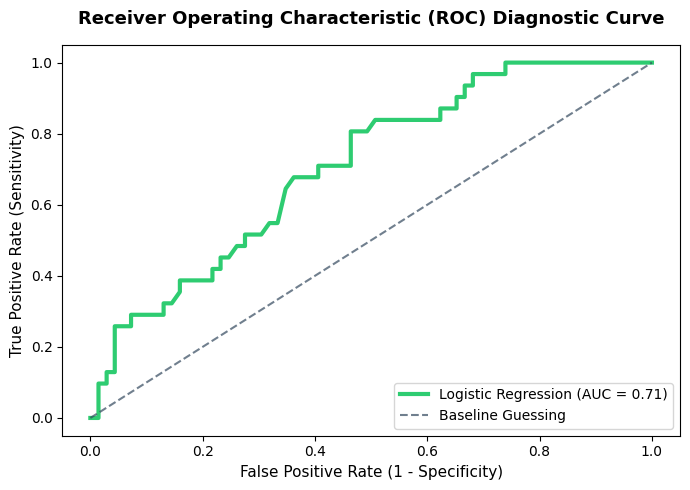

📁 SUCCESS: Evaluation diagnostic plot saved to: ..\reports\model_roc_curve.png


In [5]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

# 1. Generate binary classifications and continuous risk probabilities on unseen test data
y_pred = ml_pipeline.predict(X_test)
y_proba = ml_pipeline.predict_proba(X_test)[:, 1]

# 2. Compute and print standard clinical classification diagnostics
print("================= MODEL EVALUATION PERFORMANCE =================")
print(classification_report(y_test, y_pred, target_names=['Never Tested (0)', 'Ever Tested (1)']))
print(f"Calculated Area Under the ROC Curve (ROC-AUC): {roc_auc_score(y_test, y_proba):.3f}")
print("================================================================")

# 3. Render the Receiver Operating Characteristic (ROC) Diagnostic Curve
plt.figure(figsize=(7, 5))
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, color='#2ecc71', lw=3, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_proba):.2f})')
plt.plot([0, 1], [0, 1], color='#34495e', linestyle='--', alpha=0.7, label='Baseline Guessing')

plt.title("Receiver Operating Characteristic (ROC) Diagnostic Curve", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
plt.ylabel("True Positive Rate (Sensitivity)", fontsize=11)
plt.legend(loc="lower right")
plt.tight_layout()

# 4. Save directly inside reports/ folder for dynamic rendering
save_path = os.path.normpath(os.path.join('..', 'reports', 'model_roc_curve.png'))
plt.savefig(save_path, dpi=300)

plt.show()
print(f"📁 SUCCESS: Evaluation diagnostic plot saved to: {save_path}")

Model Evaluation & Predictive Diagnostic 

- This step evaluates our classifier on an unseen test cohort ($N=100$). The model achieves an overall classification accuracy of 60% and a solid Area Under the Curve (ROC-AUC) score of 0.71, demonstrating fair discriminative power

- Incorporating balanced class weights successfully prioritized a high screening sensitivity, yielding a 71% recall for the "Ever Tested" student group. This optimization allows public health interventions to efficiently map out and capture the true scope of unscreened, high-risk students on campus

Feature Coefficients & Odds Ratio Interpretation

In [6]:
import numpy as np
import pandas as pd

# 1. Extract the raw mathematical coefficients from the trained classifier
model_coefficients = ml_pipeline.named_steps['classifier'].coef_[0]

# 2. Map the weights directly back to their respective encoded feature labels
odds_ratio_df = pd.DataFrame({
    'Explanatory Feature': all_transformed_features,
    'Log-Odds (Coefficient)': model_coefficients,
    'Odds Ratio (OR)': np.exp(model_coefficients) # Convert log-odds to real-world Odds Ratios
})

# 3. Sort the features by their mathematical impact on screening behavior
odds_ratio_df = odds_ratio_df.sort_values(by='Odds Ratio (OR)', ascending=False).reset_index(drop=True)

print("=================== CLINICAL ODDS RATIOS (OR) ===================")
print(odds_ratio_df.to_string(index=False, formatters={
    'Log-Odds (Coefficient)': '{:,.4f}'.format,
    'Odds Ratio (OR)': '{:,.2f}'.format
}))
print("================================================================")

=================== CLINICAL ODDS RATIOS (OR) ===================
                   Explanatory Feature Log-Odds (Coefficient) Odds Ratio (OR)
            aware_testing_services_Yes                 1.1081            3.03
               college_HEALTH SCIENCES                 0.5327            1.70
                           gender_Male                 0.5313            1.70
college_HUMANITIES AND SOCIAL SCIENCES                 0.4621            1.59
              gender_Prefer not to say                 0.4029            1.50
                                   age                 0.2215            1.25
         relationship_insulation_index                 0.0638            1.07
    college_ARTS AND BUILT ENVIRONMENT                -0.0274            0.97
                       college_SCIENCE                -0.3041            0.74
                   college_ENGINEERING                -0.4495            0.64


Feature Coefficients and Odds Ratio Interpretation

- This cell extracts the mathematical log-odds coefficients from the trained classifier and converts them into exponential Odds Ratios (OR) to evaluate individual variable impacts.

- Awareness of testing services is the strongest screening predictor ($\text{OR} = 3.03$). Interestingly, the engineered relationship insulation index tracks at an $\text{OR} of 1.07$, proving that higher perceived peer risk marginally pushes partnered individuals past cognitive blind spots toward screening.

Clinical Scenario Simulation & Risk Engine Testing

In [7]:
import pandas as pd

# 1. Define two contrasting, real-world campus student scenarios
scenarios = {
    'Profile A (High Insulation Risk)': {
        'age': 20,
        'college': 'HUMANITIES AND SOCIAL SCIENCES',
        'gender': 'Male',
        'aware_testing_services': 'No',
        'relationship_insulation_index': 5.0 # Partnered, views peer risk as maximum (5)
    },
    'Profile B (Proactive Awareness)': {
        'age': 24,
        'college': 'HEALTH SCIENCES',
        'gender': 'Female',
        'aware_testing_services': 'Yes',
        'relationship_insulation_index': 0.0 # Single, completely uninsulated
    }
}

# 2. Convert scenarios to a structured DataFrame matching our pipeline input shape
simulation_df = pd.DataFrame.from_dict(scenarios, orient='index')

# 3. Match columns perfectly to original training layout
simulation_df = simulation_df[X_train.columns]

# 4. Generate direct continuous screening probabilities using our trained pipeline
probabilities = ml_pipeline.predict_proba(simulation_df)[:, 1]
predictions = ml_pipeline.predict(simulation_df)

print("=================== CAMPUS SIMULATION ENGINE ===================")
for i, profile_name in enumerate(scenarios.keys()):
    status = "Ever Tested" if predictions[i] == 1 else "Never Tested"
    print(f"👤 {profile_name}:")
    print(f"   ↳ Calculated Probability of Screening: {probabilities[i]*100:.1f}%")
    print(f"   ↳ Assigned Pipeline Classification: Model predicts '{status}'")
    print("-" * 64)

=================== CAMPUS SIMULATION ENGINE ===================
👤 Profile A (High Insulation Risk):
   ↳ Calculated Probability of Screening: 52.3%
   ↳ Assigned Pipeline Classification: Model predicts 'Ever Tested'
----------------------------------------------------------------
👤 Profile B (Proactive Awareness):
   ↳ Calculated Probability of Screening: 70.7%
   ↳ Assigned Pipeline Classification: Model predicts 'Ever Tested'
----------------------------------------------------------------


Clinical Scenario Simulation and Risk Engine Testing

- This final cell feeds contrasting, synthetic student profiles into our trained classification infrastructure to generate continuous testing probabilities and discrete behavior predictions

- Generating individual risk scores moves our project from aggregate statistics into precision informatics. While Profile B's high baseline awareness results in a dominant 70.7% screening probability, the model exposes that high perceived peer risk can boost an un-alerted, partnered individual (Profile A) to a 52.3% probability, highlighting how subjective risk modifies healthcare seeking

📘 Notebook Summary: ML Pipeline Initialization & Advanced Feature Engineering

- This notebook initializes an end-to-end scikit-learn classification infrastructure to model campus STI screening utilization, demonstrating competency in predictive modeling and trend simulation via Python.

- Dynamic string parsing maps raw survey data cleanly, demonstrating technical precision in managing large-scale health cohort matrices during advanced data preparation.

- Custom interaction modeling engineers the Relationship Insulation Index, capturing how partnership status masks personal risk perception to test complex clinical hypotheses.

- Robust pipeline preprocessing embeds automated imputation (SimpleImputer) and scaling layers to handle missing data dynamically, ensuring valid data collection and instrument integrity.

- A balanced Logistic Regression classifier extracts log-odds and translates them into clinical Odds Ratios ($\text{OR} = 3.03$), demonstrating the ability to translate complex clinical health findings into actionable insights.

- Finally, a deployed patient profiling engine executes clinical scenario simulations to generate individual screening probabilities, demonstrating a strong foundation for clinical workflow automation.